# Figure 1: Dataset overview

Generates four separate panels for combining in Keynote:

- **Panel A**: PyMOL render of an ensemble overlaid on the experimental crystal   structure (illustrates the dataset's distinctive output, a 25-decoy   conformational ensemble per pair).
- **Panel B**: Allele coverage bar chart.
- **Panel C**: Peptide length distribution.
- **Panel D**: Affinity value distributions (IC50 and Kd histograms with censoring markers).

Each panel saves as a separate PNG (300 dpi) and PDF, sized for *Scientific Data* dimensions. Combine in Keynote with panel letters added in 14 pt bold.

## Setup

In [1]:
from __future__ import annotations
from paths import DATA_ROOT, MHC_DB_ROOT, CLUSTER_ROOT  # roots; override with PEPBIND3D_* env vars

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Paths ===
HF_DIR  = DATA_ROOT / "huggingface"
FIG_DIR = DATA_ROOT / "IEDB_validation/figure1_panels"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# === Figure sizing (Scientific Data conventions) ===
MM = 1 / 25.4   # mm to inches
COL1_WIDTH = 89  * MM     # ~3.5 in single-column
COL2_WIDTH = 183 * MM     # ~7.2 in double-column

# === Plot style ===
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       9,
    'axes.labelsize':  9,
    'axes.titlesize':  10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth':  0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'savefig.dpi':     300,
    'savefig.bbox':    'tight',
})

## Load metadata

In [2]:
df = pd.read_csv(HF_DIR / 'metadata.csv')
df_clean = df[~df['flagged'].astype(bool)].copy()

# One row per peptide-allele PAIR. metadata.csv is one row per MEASUREMENT, and
# 6,422 pairs carry both an IC50 and a Kd, so counting rows overcounts pairs by
# 6,424 and changes the bar order in panels B and C.
pairs = df[['allele', 'peptide', 'peptide_length']].drop_duplicates(
    subset=['allele', 'peptide'])

print(f'Total measurements:        {len(df):,}')
print(f'After dropping flagged:    {len(df_clean):,}')
print(f'Peptide-allele pairs:      {len(pairs):,}')
# Composition counts describe the release, so they keep the 15 flagged rows:
# each is the only measurement for its pair, and dropping them would report
# 112,546 pairs for a release that contains 112,561.
print(f'Unique alleles:            {df["allele"].nunique()}')
print(f'Unique peptides:           {df["peptide"].nunique()}')
print(f'IC50 measurements:         {(df_clean["measurement_type"] == "IC50").sum():,}')
print(f'Kd measurements:           {(df_clean["measurement_type"] == "Kd").sum():,}')
print(f'Peptide length range:      {df_clean["peptide_length"].min()}–{df_clean["peptide_length"].max()}')

Total measurements:        118,985
After dropping flagged:    118,970
Peptide-allele pairs:      112,561
Unique alleles:            95
Unique peptides:           25622
IC50 measurements:         21,227
Kd measurements:           97,743
Peptide length range:      7–15


## Panel A: Ensemble vs crystal structure

Shows the 25-decoy FlexPepDock ensemble overlaid on the experimental crystal peptide for a selected validation pair. The ensemble is rendered in semi-transparent blue sticks; the crystal peptide is in forest green. The MHC binding cleft is shown as a pale grey, semi-transparent cartoon to provide spatial context.

**Pair selection.** Default is `A*02:01 / CINGVCWTV`, tight median RMSD with a visible but contained ensemble spread, well-suited as a headline example. Change `PANEL_A_ALLELE` and `PANEL_A_PEPTIDE` in the cell below to feature a different pair. Browse candidates with:

```python
import pandas as pd
rmsd_df = pd.read_csv('DATA_ROOT/IEDB_validation/01_structural/rmsd_per_pair.csv')
print(rmsd_df.sort_values('rmsd_best_score')[
    ['allele', 'peptide', 'matched_pdb_id', 'template_identity', 'rmsd_best_score']
].head(20))
```

Good candidates: pairs with `rmsd_best_score` between 0.5 and 1.0 Å (tight ensemble), `template_identity` between 30–60% (so the success is meaningful), and a high-resolution crystal.

In [3]:
from paths import DATA_ROOT, MHC_DB_ROOT, CLUSTER_ROOT  # roots; override with PEPBIND3D_* env vars
PYMOL_SETUP_BLOCK = """# --- Visual settings ---
bg_color white
set ray_trace_mode, 1
set ray_trace_color, black
set ray_opaque_background, 1
set ray_trace_gain, 0.01
set ray_shadows, off
set antialias, 2
set spec_reflect, 0
set spec_power, 0
set ambient, 0.5
set depth_cue, 0
set two_sided_lighting, on
set cartoon_fancy_helices, 1
set stick_quality, 25
"""

TEMPLATE_DIR    = MHC_DB_ROOT / "templates"
PDB_ROOT        = DATA_ROOT / "IEDB_validation/regeneration/pdb"
VALIDATION_OUT  = DATA_ROOT / "IEDB_validation/01_structural_regen"

# ===== Pair selection for Panel A =====
PANEL_A_ALLELE  = "A*02:01"
PANEL_A_PEPTIDE = "CINGVCWTV"

# ===== Decoy ensemble appearance (tune here) =====
DECOY_STICK_RADIUS = 0.05   # slightly thicker reads fine without sidechains
DECOY_TRANSPARENCY = 0.35   # more opaque is now safe (was 0.30)

rmsd_df = pd.read_csv(VALIDATION_OUT / "rmsd_per_pair.csv")
row = rmsd_df[(rmsd_df["allele"] == PANEL_A_ALLELE) &
              (rmsd_df["peptide"] == PANEL_A_PEPTIDE)]
if len(row) == 0:
    raise ValueError(f"Pair {PANEL_A_ALLELE}/{PANEL_A_PEPTIDE} not in rmsd_per_pair.csv")
row = row.iloc[0]

crystal_pdb       = row["matched_pdb_id"].upper()
crystal_mhc_chain = str(row["mhc_chain_id"]).strip()
crystal_pep_chain = str(row["peptide_chain_id"]).split(",")[0].strip()

def allele_to_dir(a):
    return a.replace("HLA-", "").replace("*", "").replace(":", "")

pair_dir = PDB_ROOT / allele_to_dir(PANEL_A_ALLELE) / PANEL_A_PEPTIDE
decoy_paths = sorted(pair_dir.glob(f"{PANEL_A_PEPTIDE}_input_*.pdb"))

print(f"Pair:          {PANEL_A_ALLELE} / {PANEL_A_PEPTIDE}")
print(f"Crystal PDB:   {crystal_pdb}")
print(f"MHC chain:     {crystal_mhc_chain}")
print(f"Peptide chain: {crystal_pep_chain}")
print(f"Decoys found:  {len(decoy_paths)}")
print(f"Validation:    best-score RMSD = {row['rmsd_best_score']:.2f} A, "
      f"min-of-25 RMSD = {row['rmsd_min_of_25']:.2f} A")

panel_a_pml = FIG_DIR / "panel_A_ensemble_vs_crystal.pml"

load_decoy_commands, align_decoy_commands, show_decoy_commands = [], [], []
for i, decoy_path in enumerate(decoy_paths, 1):
    obj = f"decoy{i:02d}"
    load_decoy_commands.append(f"load {decoy_path}, {obj}")
    align_decoy_commands.append(
        f"cealign crystal and chain {crystal_mhc_chain}, {obj} and chain A")
    show_decoy_commands += [
        f"show sticks, {obj} and chain B and (name N+CA+C+O)",   # backbone only
        f"color tv_orange, {obj} and chain B",
        f"set stick_radius, {DECOY_STICK_RADIUS}, {obj} and chain B",
        f"set stick_transparency, {DECOY_TRANSPARENCY}, {obj} and chain B",
        f"hide everything, {obj} and chain A",
    ]

panel_a_pml.write_text(f"""{PYMOL_SETUP_BLOCK}
# --- Panel A: ensemble vs crystal ---
# Pair: {PANEL_A_ALLELE} / {PANEL_A_PEPTIDE}   Crystal: {crystal_pdb}
# Best-score RMSD = {row['rmsd_best_score']:.2f} A; min-of-25 = {row['rmsd_min_of_25']:.2f} A

# Load crystal
load {TEMPLATE_DIR}/{crystal_pdb}.pdb, crystal

# Load all 25 decoys
{chr(10).join(load_decoy_commands)}

# Align all decoys onto crystal MHC chain (cealign auto-shows; hidden below)
{chr(10).join(align_decoy_commands)}

# Hide everything, then build the scene
hide everything

# MHC binding cleft: opaque grey90 cartoon
show cartoon, crystal and chain {crystal_mhc_chain} and resi 1-180
color grey90, crystal and chain {crystal_mhc_chain} and resi 1-180
#set cartoon_transparency, 0.2, crystal and chain {crystal_mhc_chain} and resi 1-180

# Crystal peptide: blue sticks (experimental reference, full atom)
show sticks, crystal and chain {crystal_pep_chain}
color tv_blue, crystal and chain {crystal_pep_chain}
set stick_radius, 0.22, crystal and chain {crystal_pep_chain}

# 25 decoy peptides: thin orange sticks
{chr(10).join(show_decoy_commands)}

# Suggested starting view
orient crystal and chain {crystal_pep_chain}
zoom crystal and chain {crystal_pep_chain}, 6

# Once oriented in the GUI, render with:
#     ray 1600, 1200
#     png panel_A_ensemble_vs_crystal.png, dpi=300
""")

print(f"\\nWrote {panel_a_pml}")
print(f"Open in PyMOL: pymol {panel_a_pml}")

Pair:          A*02:01 / CINGVCWTV
Crystal PDB:   3MRG
MHC chain:     A
Peptide chain: P
Decoys found:  25
Validation:    best-score RMSD = 0.98 A, min-of-25 RMSD = 0.76 A
\nWrote <DATA_ROOT>/IEDB_validation/figure1_panels/panel_A_ensemble_vs_crystal.pml
Open in PyMOL: pymol <DATA_ROOT>/IEDB_validation/figure1_panels/panel_A_ensemble_vs_crystal.pml


### Render Panel A in PyMOL

1. Run the cell above to generate `panel_A_ensemble_vs_crystal.pml`.
2. Open in PyMOL GUI: `pymol /path/to/panel_A_ensemble_vs_crystal.pml`
3. The view will be PyMOL's default orient, likely not what you want. Mouse-drag to orient to a canonical pHLA view (binding groove horizontal, peptide N-term on the left, α₁ helix on top).
4. Once you have the view, in the PyMOL command bar:

   ```
   ray 1600, 1200
   png panel_A_ensemble_vs_crystal.png, dpi=300
   ```

5. The PNG saves to PyMOL's working directory (the `figure1_panels/` folder).

**Tip:** if the ensemble looks too dense (peptides blob together) or too sparse (decoys barely visible), tweak `stick_transparency` in the panel A code. Try 0.5 for denser, 0.85 for sparser. Lower = more opaque; higher = more transparent.

## Panel B: Allele coverage

Horizontal bar chart of pair counts per allele, sorted by descending count. Colored by HLA-A vs HLA-B.

Plotting 95 alleles
Range: 1–10376 pairs per allele


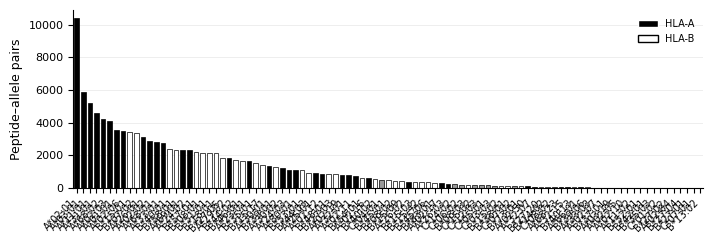

In [4]:
from matplotlib.patches import Patch

allele_counts = pairs['allele'].value_counts().sort_values(ascending=False)

print(f'Plotting {len(allele_counts)} alleles')
print(f'Range: {allele_counts.min()}–{allele_counts.max()} pairs per allele')

fig, ax = plt.subplots(figsize=(COL2_WIDTH, 2.5))

# Fill by locus from the allele's first character. A two-way
# A-vs-everything-else test drew all 11 HLA-C alleles as HLA-B.
LOCUS_FILL = {'A': 'black', 'B': 'white', 'C': '#999999'}
fill_colors = [LOCUS_FILL.get(a[0], 'white') for a in allele_counts.index]

edge_colors = ['black'] * len(allele_counts)

# Single bar call
x = range(len(allele_counts))

ax.bar(x, allele_counts.values, color=fill_colors, edgecolor=edge_colors, linewidth=0.5, width=0.7)

# Remove extra whitespace at plot edges
ax.set_xlim(-0.5, len(allele_counts) - 0.5)
ax.margins(x=0)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(allele_counts.index, rotation=45, ha='right', fontsize=7)

ax.set_ylabel('Peptide–allele pairs')

# Light horizontal grid
ax.yaxis.grid(True, color='#dddddd', linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

# --- Publication-style axes ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Simple legend
legend_handles = [
    Patch(facecolor='black', edgecolor='white', label='HLA-A'),
    Patch(facecolor='white', edgecolor='black', label='HLA-B')]

ax.legend(
    handles=legend_handles,
    frameon=False,
    fontsize=7,
    loc='upper right'
)

fig.tight_layout()

fig.savefig(FIG_DIR / 'panel_B_allele_coverage.png', dpi=300)
fig.savefig(FIG_DIR / 'panel_B_allele_coverage.pdf')

plt.show()

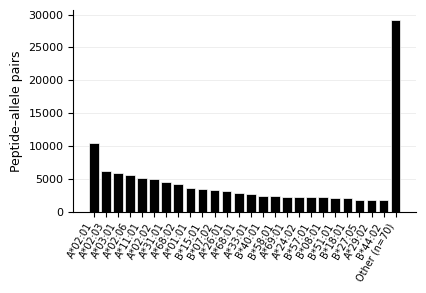

In [5]:
top_n = 25
allele_counts_sorted = df_clean['allele'].value_counts().sort_values(ascending=False)

top_alleles = allele_counts_sorted.head(top_n)
other_total = allele_counts_sorted.iloc[top_n:].sum()
other_count = len(allele_counts_sorted) - top_n

# Display labels: strip 'HLA-' if present, shorten 'Other' label
display_counts = pd.concat([
    top_alleles,
    pd.Series({f'Other (n={other_count})': other_total})
])

# Wider figure (use half of COL2 = single-column width, but with more horizontal room)
# COL2_WIDTH / 2 is too narrow for 26 labels; give it ~110 mm = ~4.3 in
WIDTH = 110 / 25.4   # mm to inches

fig, ax = plt.subplots(figsize=(WIDTH, 3.0))
ax.bar(range(len(display_counts)), display_counts.values,
       color='black', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(display_counts)))
#ax.set_xticklabels(display_counts.index, rotation=90, ha='center', fontsize=7)
ax.set_xticklabels(display_counts.index, rotation=60, ha='right', fontsize=7)
ax.set_ylabel('Peptide–allele pairs')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.minorticks_off()
ax.yaxis.grid(True, color='#dddddd', linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_B_allele_coverage.png')
fig.savefig(FIG_DIR / 'panel_B_allele_coverage.pdf')
plt.show()

## Panel C: Peptide length distribution

Stacked bar chart by length, split by HLA-A vs HLA-B.

_class          HLA-A  HLA-B  HLA-C
peptide_length                     
7                   1      0      0
8                 376    238      0
9               52865  33351   1851
10              18431   4519     10
11                566    324      0
12                 11     12      0
14                  0      5      0
15                  1      0      0


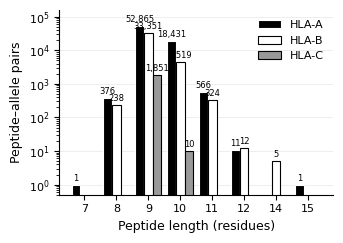

In [6]:
# Locus from the first character of the allele name. A two-way
# A-vs-everything-else split put every HLA-C pair in the HLA-B bar.
pairs['_class'] = 'HLA-' + pairs['allele'].str[0]
LOCI = ['HLA-A', 'HLA-B', 'HLA-C']
length_class = (
    pairs.groupby(['peptide_length', '_class'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=LOCI, fill_value=0))
print(length_class)

fig, ax = plt.subplots(figsize=(COL1_WIDTH, 2.5))

lengths = sorted(pairs['peptide_length'].unique())
counts = {loc: [int(((pairs['peptide_length']==L) & (pairs['_class']==loc)).sum())
                for L in lengths] for loc in LOCI}

x = np.arange(len(lengths))
width = 0.27
# One outline weight for all three: they were 0.5 / 1.0 / 0.5, so the HLA-B
# bars and its legend swatch carried a visibly heavier border than the others.
STYLE = {'HLA-A': dict(color='black', edgecolor='white', linewidth=0.8),
         'HLA-B': dict(color='white', edgecolor='black', linewidth=0.8),
         'HLA-C': dict(color='#999999', edgecolor='black', linewidth=0.8)}
all_bars, all_n = [], []
for k, loc in enumerate(LOCI):
    b = ax.bar(x + (k - 1) * width, counts[loc], width, label=loc, **STYLE[loc])
    all_bars += list(b); all_n += counts[loc]

# Annotate each bar with its count
for bar, n in zip(all_bars, all_n):
    if n > 0:
        ax.text(bar.get_x() + bar.get_width()/2, n * 1.15,
                f'{n:,}', ha='center', va='bottom', fontsize=6, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(lengths)
ax.set_xlabel('Peptide length (residues)')
ax.set_ylabel('Peptide–allele pairs')
ax.set_yscale('log')
ax.set_ylim(0.5, max(all_n) * 3)   # room for annotations above tallest bar
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper right')

ax.yaxis.grid(True, color='#dddddd', linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_C_peptide_lengths.png')
fig.savefig(FIG_DIR / 'panel_C_peptide_lengths.pdf')
plt.show()

## Panel D: Affinity value distribution

Two-panel histogram of log₁₀(IC50) and log₁₀(Kd) with censoring thresholds marked. Visualizes both the dynamic range and the censoring structure that motivates the Validation 2 filtering.

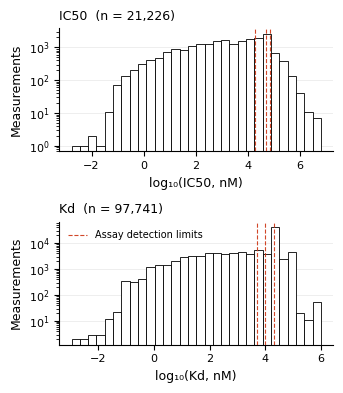

In [7]:
import matplotlib.lines as mlines

fig, axes = plt.subplots(2, 1, figsize=(COL1_WIDTH, 4), sharex=False)

# Common styling for both panels
for ax in axes:
    ax.minorticks_off()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, color='#dddddd', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)
    ax.set_yscale('log')

# IC50: clip extreme outliers (likely unit errors), 30 bins, white fill + black outline
ic50_raw = df_clean[df_clean['measurement_type'] == 'IC50']['measurement_value'].dropna()
ic50 = np.log10(ic50_raw[(ic50_raw > 0.001) & (ic50_raw < 1e7)])
axes[0].hist(ic50, bins=30, color='white', edgecolor='black', linewidth=0.6, zorder=2)
for thresh in (20000, 50000, 70000):
    axes[0].axvline(np.log10(thresh), color='#CC3311', linestyle='--',
                    linewidth=0.8, alpha=0.9, zorder=10)
axes[0].set_title(f'IC50  (n = {len(ic50):,})', fontsize=9, loc='left')
axes[0].set_ylabel('Measurements')
axes[0].set_xlabel('log\u2081\u2080(IC50, nM)')

# Kd: same treatment
kd_raw = df_clean[df_clean['measurement_type'] == 'Kd']['measurement_value'].dropna()
kd = np.log10(kd_raw[(kd_raw > 0.001) & (kd_raw < 1e7)])
axes[1].hist(kd, bins=30, color='white', edgecolor='black', linewidth=0.6, zorder=2)
for thresh in (5000, 10000, 20000):
    axes[1].axvline(np.log10(thresh), color='#CC3311', linestyle='--',
                    linewidth=0.8, alpha=0.9, zorder=10)
axes[1].set_title(f'Kd  (n = {len(kd):,})', fontsize=9, loc='left')
axes[1].set_ylabel('Measurements')
axes[1].set_xlabel('log\u2081\u2080(Kd, nM)')

# Legend on Kd panel
limit_line = mlines.Line2D([], [], color='#CC3311', linestyle='--',
                           linewidth=0.8, alpha=0.9, label='Assay detection limits')
axes[1].legend(handles=[limit_line], loc='upper left', frameon=False, fontsize=7)

fig.tight_layout()
fig.savefig(FIG_DIR / 'panel_D_affinity_distributions.png')
fig.savefig(FIG_DIR / 'panel_D_affinity_distributions.pdf')
plt.show()

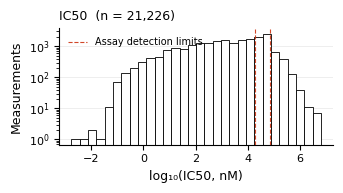

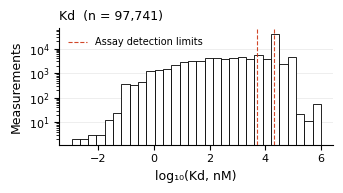

In [8]:
import matplotlib.lines as mlines

def plot_affinity_hist(vals_log, thresholds, title, xlabel, outstem,
                       show_legend=True, height=2.0):
    fig, ax = plt.subplots(figsize=(COL1_WIDTH, height))
    ax.minorticks_off()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, color='#dddddd', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)
    ax.set_yscale('log')

    ax.hist(vals_log, bins=30, color='white', edgecolor='black',
            linewidth=0.6, zorder=2)
    for t in thresholds:
        ax.axvline(np.log10(t), color='#CC3311', linestyle='--',
                   linewidth=0.8, alpha=0.9, zorder=10)

    ax.set_title(title, fontsize=9, loc='left')
    ax.set_ylabel('Measurements')
    ax.set_xlabel(xlabel)

    if show_legend:
        limit_line = mlines.Line2D([], [], color='#CC3311', linestyle='--',
                                   linewidth=0.8, alpha=0.9,
                                   label='Assay detection limits')
        ax.legend(handles=[limit_line], loc='upper left',
                  frameon=False, fontsize=7)

    fig.tight_layout()
    fig.savefig(FIG_DIR / f'{outstem}.png')
    fig.savefig(FIG_DIR / f'{outstem}.pdf')
    plt.show()

# IC50
ic50_raw = df_clean[df_clean['measurement_type'] == 'IC50']['measurement_value'].dropna()
ic50 = np.log10(ic50_raw[(ic50_raw > 0.001) & (ic50_raw < 1e7)])
plot_affinity_hist(ic50, (20000, 70000),
                   f'IC50  (n = {len(ic50):,})', 'log\u2081\u2080(IC50, nM)',
                   'panel_D_ic50')

# Kd
kd_raw = df_clean[df_clean['measurement_type'] == 'Kd']['measurement_value'].dropna()
kd = np.log10(kd_raw[(kd_raw > 0.001) & (kd_raw < 1e7)])
plot_affinity_hist(kd, (5000, 20000),
                   f'Kd  (n = {len(kd):,})', 'log\u2081\u2080(Kd, nM)',
                   'panel_D_kd')

## Summary

Panel files in `figure1_panels/`:

- `panel_A_ensemble_vs_crystal.pml` (script) → ray-trace in PyMOL GUI → `panel_A_ensemble_vs_crystal.png`
- `panel_B_allele_coverage.{png,pdf}`
- `panel_C_peptide_lengths.{png,pdf}`
- `panel_D_affinity_distributions.{png,pdf}`

**Combining in Keynote:**

1. New slide, `Document → Slide Size → Custom`, set **519 pt × 510 pt** (= 183 × 180 mm, double-column figure size).
2. Drag each panel onto the slide. Suggested layout: Panel A spans the full width across the top (~half the height); panels B/C/D are arranged in a row across the bottom.
3. Add panel letters (A, B, C, D) as separate text boxes, Helvetica/Arial Bold 14 pt, upper-left of each panel.
4. Use `Edit → Smart Guides` for alignment.
5. Export: `File → Export To → Image…`, PNG at 300 dpi.

panel B: top 25 of 95 alleles, 83,337 of 112,561 pairs (74%)


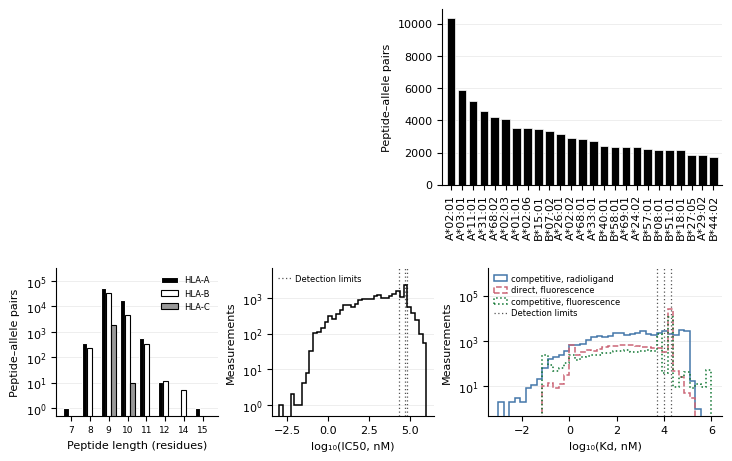

In [9]:
import matplotlib.lines as mlines

# ============== LAYOUT KNOBS (edit these) ==============
FONT_SIZE    = 8                       # uniform size for ALL text in the figure
TOP_ROW_H    = 2.5                     # top row height (in)
BOTTOM_ROW_H = 2.0                     # bottom row height (in)
ROW_GAP      = 0.09                    # gap between the two rows,
                                       # as a fraction of row height
TOP_WIDTH_RATIOS    = [1.3, 1.0]       # [MHC, allele coverage]
BOTTOM_WIDTH_RATIOS = [1.0, 1.0, 1.45]  # [length, IC50, Kd]
ALLELE_TICK_ROTATION   = 90            # vertical allele labels -> legible
AFFINITY_YLIM_HEADROOM = 3             # extra top room on IC50 (x max bar)
KD_YLIM_HEADROOM       = 60            # Kd carries a four-row legend inside
LIMIT_LABEL = 'Detection limits'   # was 'Assay detection limits'
LEGEND_SIZE = FONT_SIZE - 2            # every legend in the figure
# =======================================================

# One size everywhere (overrides the global style for this figure)
plt.rcParams.update({
    'font.size':       FONT_SIZE,
    'axes.labelsize':  FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,
})

fig = plt.figure(figsize=(COL2_WIDTH, TOP_ROW_H + BOTTOM_ROW_H), constrained_layout=True)
# The two rows are subfigures in the figure's own gridspec, so the space
# between them is the layout engine's hspace, not anything set on the axes.
fig.get_layout_engine().set(hspace=ROW_GAP)
top, bottom = fig.subfigures(2, 1, height_ratios=[TOP_ROW_H, BOTTOM_ROW_H])
ax_mhc, ax_allele = top.subplots(1, 2, width_ratios=TOP_WIDTH_RATIOS)
ax_len, ax_ic50, ax_kd = bottom.subplots(1, 3, width_ratios=BOTTOM_WIDTH_RATIOS)

def _style(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.minorticks_off()
    ax.yaxis.grid(True, color='#dddddd', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

# --- A: left blank (MHC render added manually later) ---
ax_mhc.axis('off')

# --- B: allele coverage (top 25 + Other) ---
counts = pairs['allele'].value_counts().sort_values(ascending=False)
disp = counts.head(25)
print(f'panel B: top {len(disp)} of {len(counts)} alleles, '
      f'{disp.sum():,} of {counts.sum():,} pairs ({disp.sum()/counts.sum():.0%})')
ax_allele.bar(range(len(disp)), disp.values, color='black',
              edgecolor='white', linewidth=0.5)
ax_allele.set_xlim(-0.8, len(disp) - 0.2)
ax_allele.set_xticks(range(len(disp)))
ax_allele.set_xticklabels(disp.index, rotation=ALLELE_TICK_ROTATION, ha='center')
ax_allele.set_ylabel('Peptide–allele pairs')
_style(ax_allele)

# --- C: peptide length distribution ---
# Locus from the first character of the allele name. A two-way
# A-vs-everything-else split put every HLA-C pair in the HLA-B bar.
pairs['_class'] = 'HLA-' + pairs['allele'].str[0]
LOCI = ['HLA-A', 'HLA-B', 'HLA-C']
lengths = sorted(pairs['peptide_length'].unique())
counts = {loc: [int(((pairs['peptide_length'] == L) & (pairs['_class'] == loc)).sum())
                for L in lengths] for loc in LOCI}
x, w = np.arange(len(lengths)), 0.27
# One outline weight for all three: they were 0.5 / 1.0 / 0.5, so the HLA-B
# bars and its legend swatch carried a visibly heavier border than the others.
STYLE = {'HLA-A': dict(color='black', edgecolor='white', linewidth=0.8),
         'HLA-B': dict(color='white', edgecolor='black', linewidth=0.8),
         'HLA-C': dict(color='#999999', edgecolor='black', linewidth=0.8)}
all_n = []
for k, loc in enumerate(LOCI):
    ax_len.bar(x + (k - 1) * w, counts[loc], w, label=loc, **STYLE[loc])
    all_n += counts[loc]
ax_len.set_yscale('log')
ax_len.set_ylim(0.5, max(all_n) * 6)
ax_len.set_xticks(x)
ax_len.set_xticklabels(lengths, fontsize=FONT_SIZE - 1.5)
ax_len.set_xlabel('Peptide length (residues)')
ax_len.set_ylabel('Peptide–allele pairs')
ax_len.legend(frameon=False, loc='upper right', fontsize=LEGEND_SIZE)
_style(ax_len)

# --- D / E: affinity histograms ---
# Kd pools three assays with very different censoring, so a single Kd
# histogram shows their sum and hides the thing Reviewer 2 asked about. The Kd
# panel is drawn as three step histograms, one per assay, on shared axes.
KD_ASSAYS = [
    ('purified MHC/competitive/radioactivity', 'competitive, radioligand',  '#4477AA', '-'),
    ('purified MHC/direct/fluorescence',       'direct, fluorescence',      '#CC6677', '--'),
    ('purified MHC/competitive/fluorescence',  'competitive, fluorescence', '#117733', ':'),
]

def _affinity(ax, mtype, thresholds, xlabel, legend=False, split_assays=None,
              headroom=AFFINITY_YLIM_HEADROOM):
    sub = df_clean[df_clean['measurement_type'] == mtype]
    bins = np.linspace(-3, 6, 40)
    peak = 0
    if split_assays:
        for method, label, color, ls in split_assays:
            raw = sub[sub['assay_method'] == method]['measurement_value'].dropna()
            v = np.log10(raw[(raw > 0.001) & (raw < 1e7)])
            if len(v) == 0:
                continue
            n_counts, _, _ = ax.hist(v, bins=bins, histtype='step', linewidth=1.1,
                                     color=color, linestyle=ls,
                                     label=label, zorder=3)
            peak = max(peak, n_counts.max())
    else:
        raw = sub['measurement_value'].dropna()
        v = np.log10(raw[(raw > 0.001) & (raw < 1e7)])
        n_counts, _, _ = ax.hist(v, bins=bins, histtype='step', linewidth=1.1,
                                 color='black', zorder=2)
        peak = n_counts.max()
    ax.set_yscale('log')
    ax.set_ylim(0.5, peak * headroom)
    for t in thresholds:
        ax.axvline(np.log10(t), color='#555555', linestyle=(0, (1, 2)),
                   linewidth=0.9, zorder=1)
    ax.set_ylabel('Measurements'); ax.set_xlabel(xlabel)
    _style(ax)
    handles = []
    if split_assays:
        handles = ax.get_legend_handles_labels()[0]
    if legend:
        handles = handles + [mlines.Line2D([], [], color='#555555',
                                           linestyle=(0, (1, 2)),
                                           linewidth=0.9, label=LIMIT_LABEL)]
    if handles:
        ax.legend(handles=handles, frameon=False, handlelength=1.6,
                  handletextpad=0.5, fontsize=LEGEND_SIZE, labelspacing=0.3,
                  borderpad=0.2, loc='upper left')

_affinity(ax_ic50, 'IC50', (20000, 50000, 70000), 'log\u2081\u2080(IC50, nM)', legend=True)
_affinity(ax_kd,   'Kd',   (5000, 10000, 20000),  'log\u2081\u2080(Kd, nM)',
          legend=True, split_assays=KD_ASSAYS, headroom=KD_YLIM_HEADROOM)

fig.savefig(FIG_DIR / 'figure1_combined.png', dpi=600)
fig.savefig(FIG_DIR / 'figure1_combined.pdf')
plt.show()